In [361]:
!pip install python-dotenv langchain langchain-core langchain-community langchain-google-genai langchain-anthropic chromadb langchain-text-splitters beautifulsoup4 sentence-transformers einops langchainhub langsmith faiss-cpu pydantic rank_bm25 pypdf markitdown[pdf] google-cloud-discoveryengine
!pip install langchain-google-vertexai python-dotenv


zsh:1: no matches found: markitdown[pdf]

[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [362]:
# In terminal google cloud setup
    # !curl https://sdk.cloud.google.com | bash
    # ! gcloud auth application-default login

# Auth + point everything at project pleet-d8210
# !gcloud auth application-default login
# !gcloud auth application-default set-quota-project pleet-d8210
# !gcloud config set project pleet-d8210

# Enable the APIs this notebook uses on pleet-d8210
# !gcloud services enable discoveryengine.googleapis.com --project pleet-d8210   # Grounded Generation (GenAI App Builder credit)
# !gcloud services enable aiplatform.googleapis.com --project pleet-d8210         # Vertex AI (only if you switch back to ChatVertexAI)


## Decalaration

In [363]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from langchain_core.output_parsers import JsonOutputParser
import transformers
import json
import hashlib
import numpy as np
import os
import shutil
import warnings
from pathlib import Path
from dotenv import load_dotenv
from pydantic import BaseModel
from typing import List
from langchain_community.document_loaders import PyPDFDirectoryLoader
from langchain_community.retrievers import BM25Retriever
from langchain_community.vectorstores import Chroma
from langchain_community.vectorstores.utils import filter_complex_metadata
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, END
from pydantic import BaseModel
from typing import TypedDict, List
from sentence_transformers import CrossEncoder
from langchain_community.embeddings import HuggingFaceEmbeddings
import time
import vertexai
from langchain_google_vertexai import ChatVertexAI
from sklearn.metrics.pairwise import cosine_similarity


DEBUG_QUESTION = "What is this document about?"
load_dotenv()
langchain_api_key = os.getenv("LANGCHAIN_API_KEY")
hf_token = os.getenv("HUGGINGFACEHUB_API_TOKEN")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
warnings.filterwarnings("ignore")
FAITHFULNESS_PASS_SCORE = 0.85
ABSTENTION_FAITHFULNESS_THRESHOLD = FAITHFULNESS_PASS_SCORE
MAX_FAITHFULNESS_RETRIES = 2

warnings.filterwarnings("ignore")


class QueryOutput(BaseModel):
    rewritten_query: str
    expanded_queries: List[str]
    step_back_query: str

class QueryOptimizerOutput(BaseModel):
    rewritten_query: str
    expanded_queries: List[str]
    step_back_query: str

class GraphState(TypedDict):
    query: str
    rewritten_query: str
    expanded_queries: List[str]
    step_back_query: str
    documents: List[Document]
    answer: str
    claims: List[str]
    plan: dict
    iteration: int
    retrieval_feedback: dict
    doc_scores: List[float]
    faithfulness: dict
    faithfulness_score: float
    confidence_label: str
    unsupported_claims: List[str]
    faithfulness_retry_count: int
    faithfulness_feedback: dict
    abstention: dict
    abstention_decision: str
    answer_source: str                 # grounded_documents | llm_general_knowledge
    document_evidence_found: bool      # whether PDFs supported the answer
    fallback_reason: str               # why general knowledge fallback was used
    references: List[dict]             # [{document, page, approx_line}] for grounded answers


## Models

In [364]:
from langchain_google_genai import ChatGoogleGenerativeAI

# ──────────────────────────────────────────────────────────────────────────────
# Google AI Studio (free tier) — get a key at https://aistudio.google.com/apikey
# Put it in your .env as:  GOOGLE_API_KEY=your-key-here
# This is the AI Studio API (generativelanguage.googleapis.com), which has a real
# free tier with rate limits — NOT Vertex AI, so no Cloud billing / SKU issues.
# ──────────────────────────────────────────────────────────────────────────────
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
if not GOOGLE_API_KEY:
    raise RuntimeError(
        "GOOGLE_API_KEY not set. Create a free key at https://aistudio.google.com/apikey "
        "and add GOOGLE_API_KEY=... to your .env file."
    )

GEMINI_MODEL = os.getenv("GEMINI_MODEL", "gemini-2.5-flash")
GEMINI_FLASH_MODEL = os.getenv("GEMINI_FLASH_MODEL", "gemini-2.5-flash")
print(f"Using Google AI Studio model: {GEMINI_MODEL}")

# Pro path (grounded generation, faithfulness judging)
llm = ChatGoogleGenerativeAI(
    model=GEMINI_MODEL,
    google_api_key=GOOGLE_API_KEY,
    temperature=0.3,
)

# Flash path (query rewriting, planning, fallback, metadata summarisation)
llm_flash = ChatGoogleGenerativeAI(
    model=GEMINI_FLASH_MODEL,
    google_api_key=GOOGLE_API_KEY,
    temperature=0.3,
)

llm_compression = llm_flash

structured_llm = llm.with_structured_output(QueryOutput)
structured_llm_flash = llm_flash.with_structured_output(QueryOutput)

cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
EMBEDDING_MODEL_NAME = "nomic-ai/nomic-embed-text-v1"
embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME,
    model_kwargs={"trust_remote_code": True}
)


Using Google AI Studio model: gemini-2.5-flash


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 8872.63it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
<All keys matched successfully>


In [365]:
import random

def safe_llm_invoke(llm, prompt, retries=5):
    last_error = None

    for i in range(retries):
        try:
            return llm.invoke(prompt)
        except Exception as e:
            last_error = e
            wait_time = (2 ** i) + random.uniform(0, 1)
            # print(f"[Retry {i+1}] Waiting {wait_time:.2f}s →", repr(e))
            time.sleep(wait_time)

    raise last_error

## Query Rewritting & Expansion

* User Query  ->  Query Rewriting  ->  Step-Back Query  ->  Query Expansion


| Step      | Why                                      |
| --------- | ---------------------------------------- |
| Rewrite   | cleans the query and removes ambiguity   |
| Step-back | captures **higher-level concept**        |
| Expansion | generates **multiple search variations** |


In [366]:
optimizer_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are an expert query optimizer. Return ONLY JSON."),
    ("human", """
        User Query:
        {query}

        Perform:
        1. Rewrite query
        2. Generate 3 variations
        3. Generate step-back query

        Return JSON:

        {{
        "rewritten_query": "...",
        "expanded_queries": ["...", "...", "...", "..."],
        "step_back_query": "..."
        }}
    """)
])

def query_intelligence_node(state):

    iteration = state.get("iteration", 0)

    if iteration == 0:
        query = state["query"]
        prompt = optimizer_prompt.invoke({"query": query})
    else:
        feedback = state.get("retrieval_feedback", {})
        snippets = [
            doc.page_content[:200]
            for doc in state.get("documents", [])[:2]
        ]

        refined_query = f"""
            Previous retrieval failed.

            Reason: {feedback.get("reason")}
            Max Score: {feedback.get("max_score")}
            Avg Score: {feedback.get("avg_score")}
            Missing Information: {feedback.get("missing_information")}
            Unsupported Sub-questions: {feedback.get("unsupported_sub_questions")}
            Coverage: {feedback.get("coverage")}

            The following snippets were retrieved but are NOT relevant:
            {chr(10).join(snippets)}

            IMPORTANT:
            - These snippets are incorrect or irrelevant
            - Do NOT base your query on them
            - Use them only to understand what went wrong

            Original Query:
            {state["query"]}

            Previous Rewritten Query:
            {state.get("rewritten_query")}

            Previous Expanded Query:
            {state.get("expanded_queries")}

            Previous Step_back Query:
            {state.get("step_back_query")}

            Your task:
            - Identify why retrieval failed
            - Fix the query without drifting away from user intent
            - Preserve original intent strictly
            - Improve specificity and keywords
        """
        prompt = optimizer_prompt.invoke({"query": refined_query})

    result = safe_llm_invoke(structured_llm_flash, prompt)

    return {
        "rewritten_query": result.rewritten_query,
        "expanded_queries": result.expanded_queries,
        "step_back_query": result.step_back_query
    }


## PDF Vector DB, Embeddings & Persistent Ingestion

This cell reads all PDFs from `documents/pdfs`, chunks them, stores embeddings in `storage/chroma`, and reloads the saved Chroma index when the PDFs and chunking settings have not changed.


In [367]:
from markitdown import MarkItDown
from pypdf import PdfReader

PDF_FOLDER = Path("documents/pdfs")
CHROMA_BASE_DIR = Path("storage/chroma")
DOC_METADATA_DIR = Path("storage/doc_metadata")
CHROMA_COLLECTION_NAME = "verirag-pdf-chroma"
CHUNK_SIZE = 1000
CHUNK_OVERLAP = 150
RETRIEVER_TOP_K = 5

PDF_FOLDER.mkdir(parents=True, exist_ok=True)
CHROMA_BASE_DIR.mkdir(parents=True, exist_ok=True)
DOC_METADATA_DIR.mkdir(parents=True, exist_ok=True)

_markitdown = MarkItDown()

# Approximate chars-per-page for page number estimation (markitdown loses page boundaries)
_CHARS_PER_PAGE = 3000

# Max characters of document text sent to the light LLM for summarisation
_METADATA_MAX_CHARS = 18000


def discover_pdf_files(folder: Path):
    return sorted(path for path in folder.rglob("*.pdf") if path.is_file())


def file_sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def pdf_page_count(path: Path):
    """Accurate page count straight from the PDF (markitdown loses page boundaries)."""
    try:
        return len(PdfReader(str(path)).pages)
    except Exception:
        return None


def build_ingestion_manifest(pdf_files):
    return {
        "collection_name": CHROMA_COLLECTION_NAME,
        "embedding_model": EMBEDDING_MODEL_NAME,
        "chunk_size": CHUNK_SIZE,
        "chunk_overlap": CHUNK_OVERLAP,
        "pdf_conversion": "markitdown",   # triggers Chroma rebuild if changed
        "files": [
            {
                "path": str(path.relative_to(PDF_FOLDER)),
                "bytes": path.stat().st_size,
                "sha256": file_sha256(path),
            }
            for path in pdf_files
        ],
    }


def manifest_fingerprint(manifest):
    manifest_json = json.dumps(manifest, sort_keys=True).encode("utf-8")
    return hashlib.sha256(manifest_json).hexdigest()[:16]


def manifest_path(persist_dir: Path):
    return persist_dir / "manifest.json"


def read_ingestion_manifest(persist_dir: Path):
    path = manifest_path(persist_dir)
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def write_ingestion_manifest(manifest, persist_dir: Path):
    persist_dir.mkdir(parents=True, exist_ok=True)
    with manifest_path(persist_dir).open("w", encoding="utf-8") as f:
        json.dump(manifest, f, indent=2, sort_keys=True)


def convert_pdfs_to_markdown(pdf_files: list) -> list:
    """
    Convert each PDF to Markdown using markitdown, with PyPDF as fallback.
    Markdown preserves structure (headers, lists, tables) that raw PDF text loses,
    which improves chunking quality and reduces token usage downstream.
    """
    docs = []
    for pdf_path in pdf_files:
        markdown_text = ""

        # Primary: markitdown
        try:
            result = _markitdown.convert(str(pdf_path))
            markdown_text = (result.text_content or "").strip()
        except Exception as e:
            print(f"[markitdown] {pdf_path.name} failed: {e}")

        # Fallback: PyPDFLoader (handles stale imports, image-only PDFs, etc.)
        if not markdown_text:
            print(f"[markitdown] Falling back to PyPDF for {pdf_path.name}...")
            try:
                from langchain_community.document_loaders import PyPDFLoader
                pages = PyPDFLoader(str(pdf_path)).load()
                markdown_text = "\n\n".join(
                    p.page_content for p in pages if p.page_content.strip()
                ).strip()
            except Exception as e:
                print(f"[fallback] PyPDF also failed for {pdf_path.name}: {e}")

        if not markdown_text:
            print(f"Warning: {pdf_path.name} produced no extractable text — skipping.")
            continue

        try:
            source = str(pdf_path.resolve().relative_to(PDF_FOLDER.resolve()))
        except ValueError:
            source = str(pdf_path)

        docs.append(Document(
            page_content=markdown_text,
            metadata={"source": source}
        ))

    return docs


def load_pdf_chunks(folder: Path):
    pdf_files = discover_pdf_files(folder)

    if not pdf_files:
        raise FileNotFoundError(
            f"No PDFs found in {folder.resolve()}. Add PDF files there, then rerun this cell."
        )

    print(f"Converting {len(pdf_files)} PDF(s) to Markdown via markitdown...")
    raw_documents = convert_pdfs_to_markdown(pdf_files)

    if not raw_documents:
        raise ValueError(f"PDFs were found in {folder.resolve()}, but no text could be extracted.")

    # Markdown-aware separators keep semantic blocks (headers, paragraphs) intact
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=CHUNK_SIZE,
        chunk_overlap=CHUNK_OVERLAP,
        separators=["\n## ", "\n# ", "\n### ", "\n\n", "\n", " ", ""],
        add_start_index=True,
    )
    chunks = splitter.split_documents(raw_documents)
    chunks = filter_complex_metadata(chunks)

    for index, doc in enumerate(chunks):
        doc.metadata["chunk_index"] = index
        # Approximate page number from char offset (markitdown gives no page boundaries)
        start = doc.metadata.get("start_index", 0)
        doc.metadata["page"] = start // _CHARS_PER_PAGE

    # raw_documents (full per-PDF markdown) are returned so the metadata store can
    # summarise the complete document, not just sampled chunks.
    return chunks, pdf_files, raw_documents


def stable_chunk_ids(chunks):
    ids = []
    for doc in chunks:
        metadata = doc.metadata or {}
        raw_id = "|".join([
            str(metadata.get("source", "")),
            str(metadata.get("page", "")),
            str(metadata.get("start_index", "")),
            hashlib.sha256(doc.page_content.encode("utf-8")).hexdigest(),
        ])
        ids.append(hashlib.sha256(raw_id.encode("utf-8")).hexdigest())
    return ids


def chroma_collection_count(vectorstore):
    try:
        return vectorstore._collection.count()
    except Exception:
        return None


def matching_persist_dirs(manifest):
    if not CHROMA_BASE_DIR.exists():
        return []
    matches = []
    for persist_dir in CHROMA_BASE_DIR.glob(f"index-{manifest_fingerprint(manifest)}*"):
        if persist_dir.is_dir() and read_ingestion_manifest(persist_dir) == manifest:
            matches.append(persist_dir)
    return sorted(matches, key=lambda path: path.stat().st_mtime, reverse=True)


def new_persist_dir(manifest):
    fingerprint = manifest_fingerprint(manifest)
    base_dir = CHROMA_BASE_DIR / f"index-{fingerprint}"
    if not base_dir.exists():
        return base_dir
    return CHROMA_BASE_DIR / f"index-{fingerprint}-rebuilt-{int(time.time())}"


def load_or_build_vectorstore(chunks, manifest):
    for persist_dir in matching_persist_dirs(manifest):
        vectorstore = Chroma(
            collection_name=CHROMA_COLLECTION_NAME,
            embedding_function=embeddings,
            persist_directory=str(persist_dir),
        )
        existing_count = chroma_collection_count(vectorstore)
        if existing_count == len(chunks):
            print(f"Loaded persisted Chroma index with {existing_count} chunks from {persist_dir}.")
            return vectorstore
        print(
            "Skipping persisted Chroma index: chunk count mismatch "
            f"(stored={existing_count}, current={len(chunks)}): {persist_dir}"
        )

    persist_dir = new_persist_dir(manifest)
    vectorstore = Chroma.from_documents(
        documents=chunks,
        ids=stable_chunk_ids(chunks),
        collection_name=CHROMA_COLLECTION_NAME,
        embedding=embeddings,
        persist_directory=str(persist_dir),
    )
    if hasattr(vectorstore, "persist"):
        vectorstore.persist()
    write_ingestion_manifest(manifest, persist_dir)
    print(f"Built and persisted Chroma index with {len(chunks)} chunks from {len(manifest['files'])} PDFs at {persist_dir}.")
    return vectorstore


# ──────────────────────────────────────────────────────────────────────────────
# LLM-generated, persistent, per-document metadata store
# ──────────────────────────────────────────────────────────────────────────────
# A light LLM (llm_flash) summarises each document once and we cache the result
# keyed by the file's SHA-256. Unchanged documents are never re-summarised. When a
# document is added it is summarised; when removed its metadata + markdown are pruned.

def _parse_llm_json(response, fallback):
    """Self-contained JSON parser (parse_json_response is defined in a later cell)."""
    content = response.content
    if isinstance(content, list):
        raw = " ".join(item.get("text", "") for item in content).strip()
    else:
        raw = str(content).strip()
    try:
        return json.loads(raw)
    except Exception:
        start, end = raw.find("{"), raw.rfind("}")
        if start != -1 and end > start:
            try:
                return json.loads(raw[start:end + 1])
            except Exception:
                pass
    return fallback


def _as_str_list(value):
    if isinstance(value, list):
        return [str(item).strip() for item in value if str(item).strip()]
    if isinstance(value, str) and value.strip():
        return [value.strip()]
    return []


def metadata_cache_file():
    return DOC_METADATA_DIR / "metadata_cache.json"


def read_metadata_cache():
    path = metadata_cache_file()
    if path.exists():
        try:
            return json.loads(path.read_text(encoding="utf-8"))
        except Exception:
            return {}
    return {}


def write_metadata_cache(cache):
    DOC_METADATA_DIR.mkdir(parents=True, exist_ok=True)
    metadata_cache_file().write_text(json.dumps(cache, indent=2), encoding="utf-8")


def generate_document_metadata(pdf_path: Path, full_text: str) -> dict:
    """Use the light LLM to summarise one document and collect structured metadata."""
    page_count = pdf_page_count(pdf_path)
    char_count = len(full_text)
    line_count = full_text.count("\n") + 1 if full_text else 0
    truncated = full_text[:_METADATA_MAX_CHARS]

    prompt = f"""You are a document analyst. Read the document below and produce a concise structured description.

Document file name: {pdf_path.name}

Document content (may be truncated):
{truncated}

Return STRICT JSON only, no extra text:
{{
  "summary": "3-5 sentence summary of what this document is about",
  "main_topics": ["short topic phrase", "..."],
  "key_dates": ["any important dates mentioned in the document, empty list if none"],
  "example_questions": ["5 concrete questions that THIS document can answer"]
}}
"""
    response = safe_llm_invoke(llm_flash, prompt)
    parsed = _parse_llm_json(response, {})

    return {
        "summary": str(parsed.get("summary", "")).strip() or "No summary available.",
        "main_topics": _as_str_list(parsed.get("main_topics")),
        "key_dates": _as_str_list(parsed.get("key_dates")),
        "example_questions": _as_str_list(parsed.get("example_questions")),
        "page_count": page_count,
        "char_count": char_count,
        "line_count": line_count,
    }


def write_doc_markdown(entry: dict) -> str:
    """Write one human-readable markdown file describing a document."""
    DOC_METADATA_DIR.mkdir(parents=True, exist_ok=True)
    stem = Path(entry.get("file_name", "document")).stem
    md_path = DOC_METADATA_DIR / f"{stem}.md"

    lines = [
        f"# {entry.get('file_name', 'document')}",
        "",
        f"- **Pages:** {entry.get('page_count')}",
        f"- **Lines:** {entry.get('line_count')}",
        f"- **Characters:** {entry.get('char_count')}",
        f"- **Bytes:** {entry.get('bytes')}",
        f"- **SHA256:** {entry.get('sha256')}",
        "",
        "## Summary",
        entry.get("summary", ""),
        "",
        "## Main Topics",
    ]
    topics = entry.get("main_topics", [])
    lines += [f"- {t}" for t in topics] if topics else ["- (none extracted)"]

    lines += ["", "## Key Dates"]
    dates = entry.get("key_dates", [])
    lines += [f"- {d}" for d in dates] if dates else ["- None found"]

    lines += ["", "## Example Questions This Document Can Answer"]
    questions = entry.get("example_questions", [])
    lines += [f"- {q}" for q in questions] if questions else ["- (none extracted)"]

    md_path.write_text("\n".join(lines), encoding="utf-8")
    return str(md_path)


def build_document_metadata_store(pdf_files, raw_documents):
    """
    Build/refresh the persistent per-document metadata store.
    - Reuses cached metadata for unchanged documents (keyed by SHA-256).
    - Generates metadata via the light LLM for new/changed documents.
    - Prunes metadata + markdown for documents that were removed.
    """
    cache = read_metadata_cache()

    # Map relative source -> full markdown text (from the conversion step)
    text_by_source = {
        (doc.metadata or {}).get("source", ""): (doc.page_content or "")
        for doc in raw_documents
    }

    current_hashes = set()
    doc_metadata = {}

    for pdf_path in pdf_files:
        try:
            source = str(pdf_path.resolve().relative_to(PDF_FOLDER.resolve()))
        except ValueError:
            source = str(pdf_path)

        sha = file_sha256(pdf_path)
        current_hashes.add(sha)

        if sha in cache:
            entry = cache[sha]
            entry["file_name"] = pdf_path.name        # refresh in case renamed
            entry["relative_path"] = source
            print(f"[metadata] Reusing cached metadata for {pdf_path.name}")
        else:
            print(f"[metadata] Generating metadata for {pdf_path.name} (light LLM)...")
            full_text = text_by_source.get(source, "")
            entry = generate_document_metadata(pdf_path, full_text)
            entry.update({
                "file_name": pdf_path.name,
                "relative_path": source,
                "sha256": sha,
                "bytes": pdf_path.stat().st_size,
            })
            cache[sha] = entry

        entry["md_file"] = write_doc_markdown(entry)
        doc_metadata[source] = entry

    # Prune documents that are no longer present
    for stale_hash in [h for h in cache if h not in current_hashes]:
        removed = cache.pop(stale_hash)
        md_file = removed.get("md_file")
        if md_file and Path(md_file).exists():
            try:
                Path(md_file).unlink()
            except Exception:
                pass
        print(f"[metadata] Removed metadata for deleted document: {removed.get('file_name')}")

    write_metadata_cache(cache)
    return doc_metadata


def build_corpus_overview_from_metadata(doc_metadata):
    """Build the corpus overview string (used by the fallback path) from LLM metadata."""
    lines = [
        f"Document count: {len(doc_metadata)}",
        "Document inventory (LLM-generated metadata):",
        "",
    ]
    for entry in doc_metadata.values():
        lines.append(f"### {entry.get('file_name')}")
        lines.append(
            f"- pages: {entry.get('page_count')} | lines: {entry.get('line_count')} | bytes: {entry.get('bytes')}"
        )
        dates = entry.get("key_dates", [])
        if dates:
            lines.append(f"- key dates: {', '.join(dates)}")
        lines.append(f"- summary: {entry.get('summary', '')}")
        topics = entry.get("main_topics", [])
        if topics:
            lines.append(f"- topics: {', '.join(topics)}")
        questions = entry.get("example_questions", [])
        if questions:
            lines.append("- example answerable questions:")
            for q in questions:
                lines.append(f"    * {q}")
        lines.append("")
    return "\n".join(lines)


def suggest_answerable_questions(max_questions_per_doc=3):
    """Build a helpful hint of what the corpus CAN answer, used when abstaining.
    Returns a flat list of example questions only — no document names exposed."""
    doc_metadata = globals().get("DOC_METADATA", {}) or {}
    if not doc_metadata:
        return ""

    questions = []
    seen = set()
    for entry in doc_metadata.values():
        for q in (entry.get("example_questions", []) or [])[:max_questions_per_doc]:
            q = q.strip()
            key = q.lower()
            if q and key not in seen:
                seen.add(key)
                questions.append(q)

    if not questions:
        return ""

    lines = ["", "Here are some questions I can answer:"]
    lines += [f"  - {q}" for q in questions]
    return "\n".join(lines)


documents, pdf_files, raw_documents = load_pdf_chunks(PDF_FOLDER)
ingestion_manifest = build_ingestion_manifest(pdf_files)
vectorstore = load_or_build_vectorstore(documents, ingestion_manifest)

# Build/refresh the persistent, LLM-generated document metadata store
DOC_METADATA = build_document_metadata_store(pdf_files, raw_documents)
CORPUS_OVERVIEW = build_corpus_overview_from_metadata(DOC_METADATA)
print(CORPUS_OVERVIEW[:2000])

vector_retriever = vectorstore.as_retriever(search_kwargs={"k": RETRIEVER_TOP_K})
bm25_retriever = BM25Retriever.from_documents(documents)
bm25_retriever.k = RETRIEVER_TOP_K


Converting 2 PDF(s) to Markdown via markitdown...
[markitdown] data1.pdf failed: File conversion failed after 1 attempts:
 - PdfConverter threw MissingDependencyException with message: PdfConverter recognized the input as a potential .pdf file, but the dependencies needed to read .pdf files have not been installed. To resolve this error, include the optional dependency [pdf] or [all] when installing MarkItDown. For example:

* pip install markitdown[pdf]
* pip install markitdown[all]
* pip install markitdown[pdf, ...]
* etc.

[markitdown] Falling back to PyPDF for data1.pdf...
[markitdown] data2.pdf failed: File conversion failed after 1 attempts:
 - PdfConverter threw MissingDependencyException with message: PdfConverter recognized the input as a potential .pdf file, but the dependencies needed to read .pdf files have not been installed. To resolve this error, include the optional dependency [pdf] or [all] when installing MarkItDown. For example:

* pip install markitdown[pdf]
* pip i

## RETRIEVER

In [368]:
# Retrieve top 5 results from both BM25 and Vector retrievers, then deduplicate results
def hybrid_retrieve_node(state):
    queries = (
        [state["rewritten_query"]] +
        state["expanded_queries"] +
        [state["step_back_query"]]
    )

    all_docs = []
    # print("----------------------------")
    for q in queries:
        # print("Query: ",q)
        all_docs.extend(bm25_retriever.invoke(q))
        all_docs.extend(vector_retriever.invoke(q))
        # print(all_docs)
        
    # print("----------------------------")
    # Deduplicate
    unique_docs = list({doc.page_content: doc for doc in all_docs}.values())

    return {"documents": unique_docs}

## Cross Encoder & Re-Ranking

In [369]:
# Rerank retrieved documents using cross-encoder, normalised scores and filter out low-relevance docs based on a threshold
def rerank_and_filter_node(state):

    docs = state.get("documents", [])
    query = state["query"]

    if not docs:
        return {
            "documents": [],
            "answer": "I don't know",
            "retrieval_feedback": {"reason": "no_docs"}
        }

    pairs = [(query, doc.page_content) for doc in docs]
    scores = cross_encoder.predict(pairs)
    scores = 1 / (1 + np.exp(-scores))

    doc_scores = list(zip(docs, scores))
    doc_scores.sort(key=lambda x: x[1], reverse=True)

    top_docs = doc_scores[:5]
    top_scores = [score for _, score in top_docs]
    max_score = max(top_scores)
    avg_score = sum(top_scores) / len(top_scores)
    # print(top_scores, max_score, avg_score)
    # print("----------------------------")

    # print("rerank: ",[doc for doc, _ in top_docs])
    # print("--------------------------------------")

    upper_threshold = 0.7
    lower_threshold = 0.4
    

    if max_score < lower_threshold:
        # Keep the best docs and ask the graph to retry/refine the query.
        # Do not set answer="I don't know" here, because that state value
        # prevents the generator from using later planner evidence.
        return {
            "documents": [doc for doc, _ in top_docs],
            "doc_scores": top_scores,
            "retrieval_feedback": {
                "reason": "very_low_relevance",
                "max_score": float(max_score),
                "avg_score": float(avg_score)
            }
        }

    elif max_score < upper_threshold:
        # Docs are medium-quality — pass them through without triggering a retry.
        # Only very_low_relevance burns retry budget; low_relevance documents
        # often contain the right content (e.g. structured lists, syllabuses)
        # but score lower on the QA-trained cross-encoder.
        return {
            "documents": [doc for doc, _ in top_docs],
            "doc_scores": top_scores
        }
    else:
        # print("above upper threshold")
        return {
            "documents": [doc for doc, _ in top_docs],
            "doc_scores": top_scores
        }

In [370]:
def Retry_decision_logic(state):

    iteration = state.get("iteration", 0)
    max_iterations = 2

    if state.get("retrieval_feedback") != None and iteration < max_iterations:
        return "retry"

    # If no docs → retry
    if not state.get("documents") and iteration < max_iterations:
        return "retry"

    return "generate"

def Refine_query_node(state):
    return {
        "iteration": state.get("iteration", 0) + 1
    }

## Compression Node

In [371]:
def extract_text(response):
    content = response.content

    if isinstance(content, list):
        return " ".join([item.get("text", "") for item in content]).strip()
    
    return content.strip()


def compress_documents_node(state):

    query = state["query"]
    docs = state.get("documents", [])[:5]

    if not docs:
        return {"documents": []}

    # Embed query once
    query_embedding = embeddings.embed_query(query)

    compressed_docs = []

    total_original_tokens = 0
    total_compressed_tokens = 0

    for doc in docs:

        text = doc.page_content

        # Rough token count
        total_original_tokens += len(text.split())

        # Step 1: sentence splitting (simple but effective)
        sentences = [s.strip() for s in text.split(".") if len(s.strip()) > 10]

        if not sentences:
            compressed_docs.append(doc)
            continue

        # Step 2: embed sentences
        sentence_embeddings = embeddings.embed_documents(sentences)

        # Step 3: similarity scoring
        scores = cosine_similarity(
            [query_embedding],
            sentence_embeddings
        )[0]

        # Step 4: pick top-k sentences
        top_k = min(6, len(sentences))

        top_indices = np.argsort(scores)[-top_k:]
        top_indices = sorted(top_indices)  # preserve order

        selected_sentences = [sentences[i] for i in top_indices]

        compressed_text = ". ".join(selected_sentences)

        total_compressed_tokens += len(compressed_text.split())

        # Preserve original metadata so page/source/start_index survive into the planner
        compressed_docs.append(Document(page_content=compressed_text, metadata=doc.metadata))

    if total_original_tokens > 0:
        reduction = 1 - (total_compressed_tokens / total_original_tokens)
    
    return {"documents": compressed_docs}


## Answer Planning Node

In [372]:
def build_empty_plan():
    return {
        "sub_questions": [],
        "required_info": [],
        "evidence_mapping": [],
        "expected_claims": [],
        "supported_claims": [],
        "missing_information": [],
        "risk_flags": ["insufficient_evidence"],
        "answer_mode": "abstain",
        "ordered_evidence": [],
        "evidence_references": {},
        "coverage": {
            "supported_sub_questions": 0,
            "total_sub_questions": 0,
            "sub_question_coverage": 0.0,
            "supported_claims": 0,
            "total_expected_claims": 0,
            "claim_support_ratio": 0.0
        }
    }


def parse_json_response(response, fallback):
    raw = extract_text(response)

    try:
        return json.loads(raw)
    except Exception:
        start = raw.find("{")
        end = raw.rfind("}")

        if start != -1 and end != -1 and end > start:
            try:
                return json.loads(raw[start:end + 1])
            except Exception:
                pass

    return fallback


def normalize_list(value):
    if isinstance(value, list):
        return [str(item).strip() for item in value if str(item).strip()]

    if isinstance(value, str) and value.strip():
        return [value.strip()]

    return []


def build_sentence_pool(docs):
    sentence_pool = []

    for doc_id, doc in enumerate(docs, start=1):
        metadata = doc.metadata or {}
        page_content = doc.page_content or ""
        chunk_start = metadata.get("start_index", 0)

        sentences = [
            sentence.strip()
            for sentence in page_content.replace("\n", " ").split(".")
            if len(sentence.strip()) > 10
        ]

        search_from = 0
        for sentence in sentences:
            pos = page_content.find(sentence, search_from)
            abs_char = chunk_start + (pos if pos >= 0 else search_from)
            if pos >= 0:
                search_from = pos + len(sentence)

            sentence_pool.append({
                "doc_id": f"DOC_{doc_id}",
                "text": sentence,
                "metadata": {
                    "source": metadata.get("source", "unknown"),
                    "page": metadata.get("page", 0),
                    "start_index": metadata.get("start_index", 0),
                    "approx_line": abs_char // 80 + 1,
                }
            })

    return sentence_pool


def rank_sentence_pool(query, sentence_pool, sentence_embeddings, top_k=2):
    if not sentence_pool or len(sentence_embeddings) == 0:
        return []

    query_embedding = embeddings.embed_query(query)
    scores = cosine_similarity([query_embedding], sentence_embeddings)[0]
    ranked_indices = np.argsort(scores)[::-1]

    ranked = []
    for idx in ranked_indices[:top_k]:
        ranked.append({
            "doc_id": sentence_pool[idx]["doc_id"],
            "text": sentence_pool[idx]["text"],
            "score": round(float(scores[idx]), 4),
            "metadata": sentence_pool[idx].get("metadata", {})
        })

    return ranked


def answer_planning_node(state):
    query = state["query"]
    docs = state.get("documents", [])
    empty_plan = build_empty_plan()
    previous_answer = str(state.get("answer", "") or "").strip()
    previous_claims = normalize_list(state.get("claims", []))
    previous_faithfulness = state.get("faithfulness", {}) or {}

    try:
        previous_faithfulness_score = float(
            state.get("faithfulness_score", previous_faithfulness.get("faithfulness_score", 0.0)) or 0.0
        )
    except Exception:
        previous_faithfulness_score = 0.0

    try:
        faithfulness_retry_count = int(state.get("faithfulness_retry_count", 0) or 0)
    except Exception:
        faithfulness_retry_count = 0

    is_faithfulness_retry = (
        previous_answer
        and previous_answer != "I don't know"
        and previous_faithfulness_score < FAITHFULNESS_PASS_SCORE
        and faithfulness_retry_count < MAX_FAITHFULNESS_RETRIES
    )

    retry_updates = {}
    if is_faithfulness_retry:
        retry_updates = {
            "faithfulness_retry_count": faithfulness_retry_count + 1,
            "faithfulness_feedback": {
                "previous_answer": previous_answer,
                "previous_claims": previous_claims,
                "judge_analysis": previous_faithfulness,
                "faithfulness_score": previous_faithfulness_score,
                "retry_number": faithfulness_retry_count + 1
            }
        }

    if not docs:
        return {
            "plan": empty_plan,
            "retrieval_feedback": {
                "reason": "planner_found_no_documents",
                "missing_information": ["No retrieved evidence available for answer planning."],
                "unsupported_sub_questions": [query]
            },
            **retry_updates
        }

    context_blocks = [
        f"[DOC_{idx}] {doc.page_content}"
        for idx, doc in enumerate(docs, start=1)
    ]
    context = "\n\n".join(context_blocks)
    retry_guidance = ""

    if is_faithfulness_retry:
        retry_guidance = f"""
Previous generation failed the Faithfulness Judge.
Faithfulness retry: {faithfulness_retry_count + 1}/{MAX_FAITHFULNESS_RETRIES}

Previous answer:
{previous_answer}

Previous claims:
{json.dumps(previous_claims, indent=2)}

Judge analysis:
{json.dumps(previous_faithfulness, indent=2)}

When creating the new plan:
- Do not repeat unsupported, weakly supported, or contradicted claims.
- Keep expected_claims only to facts directly backed by the context.
- Prefer evidence sentences that directly support each claim.
"""

    prompt = f"""
You are an answer planning engine for a RAG system.

Your job is to create a plan that can be executed before final generation.

Given:
Question: {query}

Context:
{context}

{retry_guidance}

Instructions:
1. Break the question into 2 to 4 answerable sub-questions
2. List the key information required
3. List atomic factual claims that a good answer would make
4. If the context is missing key evidence or looks conflicting, set answer_mode to "abstain"
5. Use ONLY the given context

Return STRICT JSON:

{{
  "sub_questions": ["...", "..."],
  "required_info": ["...", "..."],
  "expected_claims": ["...", "..."],
  "missing_information": ["..."],
  "risk_flags": ["insufficient_evidence"],
  "answer_mode": "grounded_answer"
}}
"""
    response = safe_llm_invoke(llm_flash, prompt)
    plan = parse_json_response(response, build_empty_plan())

    plan["sub_questions"] = normalize_list(plan.get("sub_questions"))
    plan["required_info"] = normalize_list(plan.get("required_info"))
    plan["expected_claims"] = normalize_list(plan.get("expected_claims"))
    plan["missing_information"] = normalize_list(plan.get("missing_information"))
    plan["risk_flags"] = normalize_list(plan.get("risk_flags"))

    if len(plan["sub_questions"]) < 2:
        plan["sub_questions"] = [
            f"What is the direct answer to: {query}?",
            "Which retrieved facts support that answer?"
        ]

    if not plan["required_info"]:
        plan["required_info"] = [f"Evidence needed to answer: {query}"]

    plan["answer_mode"] = "abstain" if plan.get("answer_mode") == "abstain" else "grounded_answer"

    sentence_pool = build_sentence_pool(docs)
    sentence_texts = [item["text"] for item in sentence_pool]
    sentence_embeddings = embeddings.embed_documents(sentence_texts) if sentence_texts else []

    min_support_score = 0.2
    evidence_mapping = []
    ordered_evidence = []
    evidence_references = {}   # text -> {document, page, approx_line}
    supported_sub_questions = []

    for sub_question in plan["sub_questions"]:
        ranked = rank_sentence_pool(sub_question, sentence_pool, sentence_embeddings, top_k=2)
        supporting = [item for item in ranked if item["score"] >= min_support_score]

        if supporting:
            supported_sub_questions.append(sub_question)

        evidence_mapping.append({
            "sub_question": sub_question,
            "supporting_sentences": [item["text"] for item in supporting],
            "source_docs": [item["doc_id"] for item in supporting],
            "support_score": supporting[0]["score"] if supporting else 0.0
        })

        for item in supporting:
            if item["text"] not in ordered_evidence:
                ordered_evidence.append(item["text"])
            if item["text"] not in evidence_references:
                meta = item.get("metadata", {})
                evidence_references[item["text"]] = {
                    "document": meta.get("source", "unknown"),
                    "page": meta.get("page", 0) + 1,       # 1-indexed for display
                    "approx_line": meta.get("approx_line", 0),
                }

    supported_claims = []
    for claim in plan["expected_claims"]:
        ranked = rank_sentence_pool(claim, sentence_pool, sentence_embeddings, top_k=1)

        if ranked and ranked[0]["score"] >= min_support_score:
            supported_claims.append(claim)
            text = ranked[0]["text"]

            if text not in ordered_evidence:
                ordered_evidence.append(text)
            if text not in evidence_references:
                meta = ranked[0].get("metadata", {})
                evidence_references[text] = {
                    "document": meta.get("source", "unknown"),
                    "page": meta.get("page", 0) + 1,
                    "approx_line": meta.get("approx_line", 0),
                }

    if not supported_claims and ordered_evidence:
        supported_claims = ordered_evidence[:min(3, len(ordered_evidence))]

    sub_question_coverage = round(
        len(supported_sub_questions) / max(1, len(plan["sub_questions"])),
        2
    )
    claim_support_ratio = round(
        len(supported_claims) / max(1, len(plan["expected_claims"])),
        2
    ) if plan["expected_claims"] else round(float(bool(supported_claims)), 2)

    plan["evidence_mapping"] = evidence_mapping
    plan["supported_claims"] = supported_claims
    plan["ordered_evidence"] = ordered_evidence
    plan["evidence_references"] = evidence_references
    plan["coverage"] = {
        "supported_sub_questions": len(supported_sub_questions),
        "total_sub_questions": len(plan["sub_questions"]),
        "sub_question_coverage": sub_question_coverage,
        "supported_claims": len(supported_claims),
        "total_expected_claims": len(plan["expected_claims"]),
        "claim_support_ratio": claim_support_ratio
    }

    risk_flags = set(plan["risk_flags"])

    if sub_question_coverage < 1.0 or not ordered_evidence:
        risk_flags.add("insufficient_evidence")

    if plan["expected_claims"] and claim_support_ratio < 1.0:
        risk_flags.add("unsupported_claims")

    plan["risk_flags"] = sorted(risk_flags)

    if (
        "conflicting_evidence" in plan["risk_flags"]
        or plan["answer_mode"] == "abstain"
        or sub_question_coverage < 0.3
        or not supported_claims
        or not ordered_evidence
    ):
        plan["answer_mode"] = "abstain"
    else:
        plan["answer_mode"] = "grounded_answer"

    if plan["answer_mode"] == "abstain" and "insufficient_evidence" in plan["risk_flags"]:
        unsupported = [
            item["sub_question"]
            for item in evidence_mapping
            if not item["supporting_sentences"]
        ]

        return {
            "plan": plan,
            "retrieval_feedback": {
                "reason": "planner_detected_missing_evidence",
                "missing_information": plan["missing_information"],
                "unsupported_sub_questions": unsupported or plan["sub_questions"],
                "coverage": plan["coverage"]
            },
            **retry_updates
        }

    return {"plan": plan, **retry_updates}


def planning_decision_logic(state):
    iteration = state.get("iteration", 0)
    max_iterations = 2
    plan = state.get("plan", {})
    risk_flags = plan.get("risk_flags", [])

    if (
        plan.get("answer_mode") == "abstain"
        and "insufficient_evidence" in risk_flags
        and iteration < max_iterations
    ):
        return "retry"

    return "generate"


## GENERATION

In [373]:
def general_knowledge_fallback_answer(state, reason):
    query = state["query"]
    corpus_overview = globals().get("CORPUS_OVERVIEW", "PDF corpus overview is unavailable.")
    corpus_overview = corpus_overview[:4000]  # cap to keep prompt size bounded
    prompt = f"""
The normal grounded RAG path did not find enough direct evidence to answer this question.
You still have access to the PDF corpus inventory, metadata, and representative excerpts below.

PDF corpus overview:
{corpus_overview}

Question:
{query}

Instructions:
- First, answer from the PDF corpus overview when the question asks about the database, number of PDFs, filenames, document metadata, or broad topics covered by the PDFs.
- If the PDF overview is enough to answer, say the answer is based on PDF metadata/representative excerpts, not a fully grounded passage-level answer.
- If the question asks for facts not present in the PDF overview or retrieved evidence, answer from general knowledge and clearly say the PDFs did not contain supporting evidence.
- Be concise and helpful.
- If the question requires private, current, personal, legal, medical, or financial certainty that you do not have, say what you can and cannot know.
- Return STRICT JSON only:

{{
  "answer": "...",
  "claims": ["...", "..."]
}}
"""

    response = safe_llm_invoke(llm_flash, prompt)
    result = parse_json_response(response, {"answer": "I don't know", "claims": []})
    answer = str(result.get("answer", "")).strip() or "I don't know"
    claims = normalize_list(result.get("claims", []))

    if answer == "I don't know":
        claims = []
    elif not claims:
        claims = [answer]

    labelled_answer = (
        "The grounded document-retrieval path did not find direct supporting evidence. "
        "This answer is generated using the PDF corpus metadata/representative excerpts when relevant, "
        "and otherwise the LLM's general knowledge: "
        f"{answer}"
    )

    return {
        "answer": labelled_answer,
        "claims": claims,
        "answer_source": "llm_general_knowledge",
        "document_evidence_found": False,
        "fallback_reason": reason,
        "references": [],
    }


def generate_answer_node(state):

    docs = state.get("documents", [])
    plan = state.get("plan", build_empty_plan())

    if not docs:
        return general_knowledge_fallback_answer(state, "no_retrieved_documents")

    if not plan or plan.get("answer_mode") != "grounded_answer":
        return general_knowledge_fallback_answer(state, "documents_do_not_contain_enough_evidence")

    ordered_evidence = plan.get("ordered_evidence", [])
    supported_claims = plan.get("supported_claims", [])

    if not ordered_evidence or not supported_claims:
        return general_knowledge_fallback_answer(state, "no_supported_claims_or_ordered_evidence")

    prompt = f"""
You are a strict grounded answer generator.

Question:
{state["query"]}

Sub-questions:
{json.dumps(plan.get("sub_questions", []), indent=2)}

Evidence mapping:
{json.dumps(plan.get("evidence_mapping", []), indent=2)}

Allowed evidence sentences:
{json.dumps(ordered_evidence, indent=2)}

Supported claims you MAY use:
{json.dumps(supported_claims, indent=2)}

Instructions:
- Use ONLY the allowed evidence sentences
- Answer the question directly and concisely
- Keep claims atomic and factual
- Claims must stay within the supported_claims list
- If the evidence is not enough, return "I don't know"

Return STRICT JSON:

{{
  "answer": "...",
  "claims": ["...", "..."]
}}
"""

    response = safe_llm_invoke(llm, prompt)
    result = parse_json_response(response, {"answer": "I don't know", "claims": []})

    result["claims"] = normalize_list(result.get("claims"))
    allowed_claims = set(supported_claims)
    filtered_claims = [claim for claim in result["claims"] if claim in allowed_claims]

    if not filtered_claims:
        filtered_claims = supported_claims

    if not filtered_claims:
        return general_knowledge_fallback_answer(state, "grounded_generation_returned_no_supported_claims")

    # Build deduplicated references from evidence sentences used in this answer
    evidence_refs = plan.get("evidence_references", {})
    references = []
    seen = set()
    for evidence_text in ordered_evidence:
        ref = evidence_refs.get(evidence_text)
        if ref:
            key = (ref["document"], ref["page"])
            if key not in seen:
                seen.add(key)
                references.append(ref)

    return {
        "answer": " ".join(filtered_claims),
        "claims": filtered_claims,
        "answer_source": "grounded_documents",
        "document_evidence_found": True,
        "fallback_reason": "",
        "references": references,
    }


## Faithfulness Judge Node

In [374]:
def build_empty_faithfulness_result(reason="not_evaluated"):
    return {
        "faithfulness_score": 0.0,
        "evidence_coverage_score": 0.0,
        "retrieval_confidence": 0.0,
        "final_confidence": 0.0,
        "confidence_label": "low",
        "claim_judgments": [],
        "unsupported_claims": [],
        "weakly_supported_claims": [],
        "contradicted_claims": [],
        "reason": reason
    }


def clamp_score(value):
    try:
        return max(0.0, min(1.0, float(value)))
    except Exception:
        return 0.0


def normalize_claim_status(status):
    status = str(status).strip().lower().replace(" ", "_").replace("-", "_")

    if status in {"supported", "fully_supported", "entailed"}:
        return "supported"

    if status in {"partial", "partially_supported", "weakly_supported", "mixed"}:
        return "partially_supported"

    if status in {"contradicted", "contradiction", "conflicting"}:
        return "contradicted"

    return "unsupported"


def confidence_label_from_score(score):
    score = clamp_score(score)

    if score >= 0.85:
        return "high"

    if score >= 0.60:
        return "medium"

    return "low"


def get_evidence_sentences(state):
    plan = state.get("plan", {}) or {}
    ordered_evidence = normalize_list(plan.get("ordered_evidence", []))

    if ordered_evidence:
        return ordered_evidence

    docs = state.get("documents", [])
    sentences = []

    for doc in docs:
        for sentence in doc.page_content.replace("\n", " ").split("."):
            sentence = sentence.strip()

            if len(sentence) > 10:
                sentences.append(sentence)

    return sentences


def calculate_retrieval_confidence(state):
    doc_scores = state.get("doc_scores", []) or []

    if not doc_scores:
        return 0.0

    return round(sum(clamp_score(score) for score in doc_scores) / len(doc_scores), 4)


def fallback_claim_judgments(claims, evidence_sentences):
    if not claims:
        return []

    if not evidence_sentences:
        return [
            {
                "claim": claim,
                "status": "unsupported",
                "supporting_doc_ids": [],
                "support_score": 0.0,
                "reason": "No evidence sentences were available."
            }
            for claim in claims
        ]

    evidence_embeddings = embeddings.embed_documents(evidence_sentences)
    judgments = []

    for claim in claims:
        claim_embedding = embeddings.embed_query(claim)
        scores = cosine_similarity([claim_embedding], evidence_embeddings)[0]
        best_idx = int(np.argmax(scores))
        best_score = clamp_score(scores[best_idx])

        if best_score >= 0.75:
            status = "supported"
        elif best_score >= 0.55:
            status = "partially_supported"
        else:
            status = "unsupported"

        judgments.append({
            "claim": claim,
            "status": status,
            "supporting_doc_ids": [f"EVIDENCE_{best_idx + 1}"],
            "support_score": round(best_score, 4),
            "reason": f"Fallback embedding similarity matched evidence sentence {best_idx + 1}."
        })

    return judgments


def score_claim_judgments(claim_judgments):
    score_map = {
        "supported": 1.0,
        "partially_supported": 0.5,
        "unsupported": 0.0,
        "contradicted": 0.0
    }

    normalized = []

    for item in claim_judgments:
        claim = str(item.get("claim", "")).strip()

        if not claim:
            continue

        status = normalize_claim_status(item.get("status", "unsupported"))
        normalized.append({
            "claim": claim,
            "status": status,
            "supporting_doc_ids": normalize_list(item.get("supporting_doc_ids", [])),
            "support_score": clamp_score(item.get("support_score", score_map[status])),
            "reason": str(item.get("reason", "")).strip()
        })

    if not normalized:
        return normalized, 0.0

    score = sum(score_map[item["status"]] for item in normalized) / len(normalized)
    return normalized, round(score, 4)


def faithfulness_judge_node(state):
    answer = str(state.get("answer", "")).strip()
    claims = normalize_list(state.get("claims", []))

    if state.get("answer_source") == "llm_general_knowledge":
        result = build_empty_faithfulness_result("general_knowledge_fallback_not_judged_against_documents")
        result.update({
            "faithfulness_score": 1.0,
            "evidence_coverage_score": 0.0,
            "retrieval_confidence": calculate_retrieval_confidence(state),
            "final_confidence": 0.0,
            "confidence_label": "general_knowledge",
            "claim_judgments": [],
            "unsupported_claims": [],
            "weakly_supported_claims": [],
            "contradicted_claims": [],
        })
        return {
            "faithfulness": result,
            "faithfulness_score": result["faithfulness_score"],
            "confidence_label": result["confidence_label"],
            "unsupported_claims": result["unsupported_claims"],
        }

    if not answer or answer == "I don't know":
        result = build_empty_faithfulness_result("answer_abstained_or_empty")
        result["confidence_label"] = "abstained"
        return {
            "faithfulness": result,
            "faithfulness_score": result["faithfulness_score"],
            "confidence_label": result["confidence_label"],
            "unsupported_claims": result["unsupported_claims"]
        }

    if not claims:
        claims = [answer]

    evidence_sentences = get_evidence_sentences(state)
    evidence_context = "\n".join(
        f"[EVIDENCE_{idx}] {sentence}"
        for idx, sentence in enumerate(evidence_sentences, start=1)
    )

    prompt = f"""
You are a strict faithfulness evaluator for a RAG system.

Question:
{state["query"]}

Answer:
{answer}

Atomic answer claims:
{json.dumps(claims, indent=2)}

Evidence:
{evidence_context}

Instructions:
- Use ONLY the evidence above.
- Judge whether each claim is supported by the evidence.
- Do not use outside knowledge.
- Mark a claim as "supported" only when the evidence directly supports it.
- Mark a claim as "partially_supported" when evidence is related but incomplete.
- Mark a claim as "unsupported" when evidence does not prove it.
- Mark a claim as "contradicted" when evidence conflicts with it.

Return STRICT JSON:
{{
  "claim_judgments": [
    {{
      "claim": "...",
      "status": "supported | partially_supported | unsupported | contradicted",
      "supporting_doc_ids": ["EVIDENCE_1"],
      "reason": "short reason"
    }}
  ]
}}
"""

    fallback = {"claim_judgments": fallback_claim_judgments(claims, evidence_sentences)}
    response = safe_llm_invoke(llm, prompt)
    judged = parse_json_response(response, fallback)
    claim_judgments = judged.get("claim_judgments") or fallback["claim_judgments"]
    claim_judgments, faithfulness_score = score_claim_judgments(claim_judgments)

    plan = state.get("plan", {}) or {}
    coverage = plan.get("coverage", {}) or {}
    evidence_coverage_score = clamp_score(coverage.get("claim_support_ratio", faithfulness_score))
    retrieval_confidence = calculate_retrieval_confidence(state)
    final_confidence = round(
        (0.55 * faithfulness_score)
        + (0.30 * evidence_coverage_score)
        + (0.15 * retrieval_confidence),
        4
    )

    unsupported_claims = [
        item["claim"]
        for item in claim_judgments
        if item["status"] == "unsupported"
    ]
    weakly_supported_claims = [
        item["claim"]
        for item in claim_judgments
        if item["status"] == "partially_supported"
    ]
    contradicted_claims = [
        item["claim"]
        for item in claim_judgments
        if item["status"] == "contradicted"
    ]

    confidence_label = confidence_label_from_score(final_confidence)

    if contradicted_claims:
        confidence_label = "low"

    result = {
        "faithfulness_score": faithfulness_score,
        "evidence_coverage_score": round(evidence_coverage_score, 4),
        "retrieval_confidence": retrieval_confidence,
        "final_confidence": final_confidence,
        "confidence_label": confidence_label,
        "claim_judgments": claim_judgments,
        "unsupported_claims": unsupported_claims,
        "weakly_supported_claims": weakly_supported_claims,
        "contradicted_claims": contradicted_claims,
        "reason": "Confidence combines claim faithfulness, planner evidence coverage, and retrieval scores."
    }

    # print("✅ Faithfulness Judge:", {
    #     "faithfulness_score": result["faithfulness_score"],
    #     "final_confidence": result["final_confidence"],
    #     "confidence_label": result["confidence_label"],
    #     "unsupported_claims": result["unsupported_claims"],
    #     "weakly_supported_claims": result["weakly_supported_claims"],
    #     "contradicted_claims": result["contradicted_claims"]
    # })

    return {
        "faithfulness": result,
        "faithfulness_score": result["faithfulness_score"],
        "confidence_label": result["confidence_label"],
        "unsupported_claims": result["unsupported_claims"]
    }


def abstention_threshold_node(state):
    answer = str(state.get("answer", "") or "").strip()
    faithfulness = state.get("faithfulness", {}) or {}
    faithfulness_score = clamp_score(
        faithfulness.get("faithfulness_score", state.get("faithfulness_score", 0.0))
    )
    final_confidence = clamp_score(faithfulness.get("final_confidence", 0.0))
    retry_count = int(state.get("faithfulness_retry_count", 0) or 0)
    unsupported_claims = normalize_list(faithfulness.get("unsupported_claims", state.get("unsupported_claims", [])))
    weakly_supported_claims = normalize_list(faithfulness.get("weakly_supported_claims", []))
    contradicted_claims = normalize_list(faithfulness.get("contradicted_claims", []))

    abstention = {
        "threshold": ABSTENTION_FAITHFULNESS_THRESHOLD,
        "faithfulness_score": faithfulness_score,
        "final_confidence": final_confidence,
        "retry_count": retry_count,
        "max_retries": MAX_FAITHFULNESS_RETRIES,
        "unsupported_claims": unsupported_claims,
        "weakly_supported_claims": weakly_supported_claims,
        "contradicted_claims": contradicted_claims,
        "rejected_answer": ""
    }

    if state.get("answer_source") == "llm_general_knowledge" and answer and answer != "I don't know":
        abstention.update({
            "decision": "accept",
            "reason": "accepted_general_knowledge_fallback_no_document_evidence"
        })
        return {
            "abstention": abstention,
            "abstention_decision": "accept"
        }

    if not answer or answer == "I don't know":
        abstention.update({
            "decision": "abstain",
            "reason": "answer_abstained_or_empty"
        })
        return {
            "answer": "I don't know." + suggest_answerable_questions(),
            "claims": [],
            "abstention": abstention,
            "abstention_decision": "abstain"
        }

    has_hard_failure = bool(unsupported_claims or contradicted_claims)
    passes_threshold = faithfulness_score >= ABSTENTION_FAITHFULNESS_THRESHOLD and not has_hard_failure

    if passes_threshold:
        abstention.update({
            "decision": "accept",
            "reason": "faithfulness_passed_threshold"
        })
        # print("🟢 Abstention Threshold:", abstention)
        return {
            "abstention": abstention,
            "abstention_decision": "accept"
        }

    if retry_count < MAX_FAITHFULNESS_RETRIES:
        abstention.update({
            "decision": "retry",
            "reason": "faithfulness_below_threshold_or_has_unsupported_claims"
        })
        # print(
        #     f"🟡 Abstention Threshold: retry {retry_count + 1}/{MAX_FAITHFULNESS_RETRIES} "
        #     f"because score={faithfulness_score:.2f}, threshold={ABSTENTION_FAITHFULNESS_THRESHOLD:.2f}, "
        #     f"unsupported={len(unsupported_claims)}, contradicted={len(contradicted_claims)}"
        # )
        return {
            "abstention": abstention,
            "abstention_decision": "retry"
        }

    abstention.update({
        "decision": "abstain",
        "reason": "faithfulness_failed_after_max_retries",
        "rejected_answer": answer
    })
    # print("🔴 Abstention Threshold: abstaining after max retries", abstention)
    return {
        "answer": "I don't know." + suggest_answerable_questions(),
        "claims": [],
        "abstention": abstention,
        "abstention_decision": "abstain"
    }


def abstention_decision_logic(state):
    return state.get("abstention_decision", "abstain")


## Graph Compliation

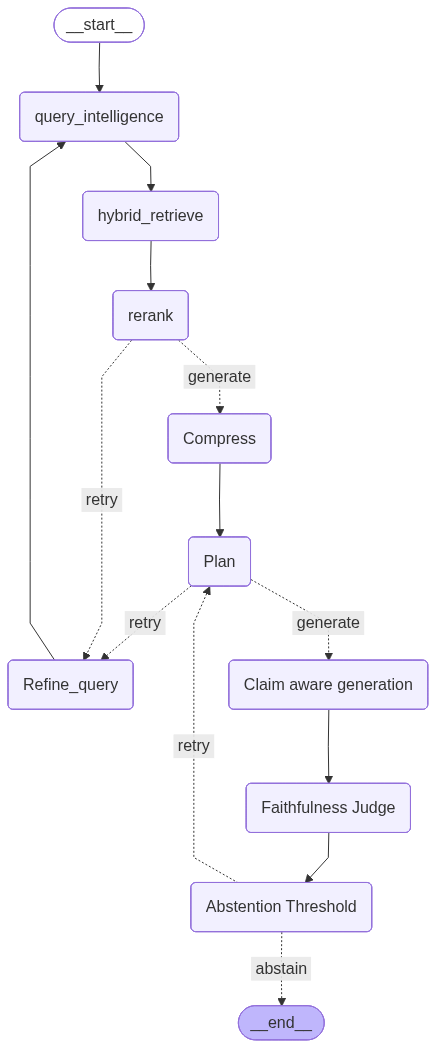

In [375]:
builder = StateGraph(GraphState)

builder.add_node("query_intelligence", query_intelligence_node)
builder.add_node("hybrid_retrieve", hybrid_retrieve_node)
builder.add_node("rerank", rerank_and_filter_node)
builder.add_node("Refine_query", Refine_query_node)
builder.add_node("Claim aware generation", generate_answer_node)
builder.add_node("Faithfulness Judge", faithfulness_judge_node)
builder.add_node("Abstention Threshold", abstention_threshold_node)
builder.add_node("Plan", answer_planning_node)
builder.add_node("Compress", compress_documents_node)

builder.set_entry_point("query_intelligence")

builder.add_edge("query_intelligence", "hybrid_retrieve")
builder.add_edge("hybrid_retrieve", "rerank")
builder.add_edge("Compress", "Plan")

builder.add_conditional_edges(
    "rerank",
    Retry_decision_logic,
    {
        "retry": "Refine_query",
        "generate": "Compress"
    }
)

builder.add_conditional_edges(
    "Plan",
    planning_decision_logic,
    {
        "retry": "Refine_query",
        "generate": "Claim aware generation"
    }
)

builder.add_edge("Refine_query", "query_intelligence")
builder.add_edge("Claim aware generation", "Faithfulness Judge")
builder.add_edge("Faithfulness Judge", "Abstention Threshold")

builder.add_conditional_edges(
    "Abstention Threshold",
    abstention_decision_logic,
    {
        "retry": "Plan",
        "accept": END,
        "abstain": END
    }
)

graph = builder.compile()

from IPython.display import Image, display # type: ignore
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))



## Ask Questions From Your PDFs

After the PDF ingestion cell and graph compilation cell have run, ask questions that are answerable from the PDFs in `documents/pdfs`.


In [376]:
# Replace this with any question. If PDFs do not contain evidence, the answer will use general LLM knowledge and say so.
question = "What is this document about?"

result = graph.invoke({
    "query": question,
    "iteration": 0,
    "faithfulness_retry_count": 0
})

raw = result.get("answer", "")

if isinstance(raw, list) and len(raw) > 0:
    print(raw[0].get("text", ""))
else:
    print(raw)

print("\nanswer_source:", result.get("answer_source"))
print("document_evidence_found:", result.get("document_evidence_found"))
print("fallback_reason:", result.get("fallback_reason"))

references = result.get("references", [])
if references and result.get("answer_source") == "grounded_documents":
    print("\nReferences:")
    for i, ref in enumerate(references, 1):
        doc  = ref.get("document", "unknown")
        page = ref.get("page", "?")
        line = ref.get("approx_line", "?")
        print(f"  [{i}] Document: {doc} | Page: {page} | Approx. Line: {line}")


LangGraph represents the RAG workflow as nodes and conditional edges. Step-back queries capture the broader concept behind a question. The document describes retrieval, including BM25 and dense retrieval. Cross-encoders rerank query-document pairs jointly. Faithfulness measures whether generated answers are supported by retrieved documents. Traces show prompts, intermediate state, model responses, and routing decisions. Enterprise policy document HR-003 states sick leave should be reported before the start of the workday when possible. Enterprise policy document HR-004 states parental leave eligibility begins after six months of continuous employment. Enterprise policy document HR-001 states full-time employees receive 18 paid vacation days per calendar year. Enterprise policy document HR-002 requires employees to request vacation at least five business days before the planned leave date.

answer_source: grounded_documents
document_evidence_found: True
fallback_reason: 

References:
  